# Cetakia Best Model V2 - Evaluation Visualization

Notebook ini dipakai untuk evaluasi **realistis** kondisi model Best Model V2 saat ini: kualitas ekstraksi field, pola error, hard cases prioritas, dan performa latency untuk produksi.

## Tujuan Evaluasi
- Mengukur akurasi ekstraksi per-field dan overall terhadap ground truth.
- Mengukur latency aktual dan gap terhadap target produksi (`< 1s`).
- Menganalisis error secara terstruktur: `miss`, `wrong_value`, `over_extract`, template-level risk.
- Memantau hard cases prioritas debugging secara eksplisit (33.jpg, 311.jpeg, 61.jpg, 39.jpg, 5.jpg).

## Update Terbaru yang Sudah Diakomodasi (26 Mei 2026)
- Penambahan dan perapihan rules parser `reference_no` (anchor `No. Transaksi`, `transaction reference`, anti-noise fee/amount/account pattern).
- Perbaikan parser DANA untuk `account_no` (mendukung `Akun DANA`) dan `recipient_name` (masked-name resolution via lexicon).
- Penambahan selective raw OCR retry untuk `reference_no` khusus layout Seabank saat anchor ada tetapi nilai belum terbaca kuat.
- Guard fallback agar `reference_no` low-confidence dari model tidak meng-overwrite hasil rule menjadi noise.
- Fix 5 hard cases utama tanpa mengubah arsitektur besar pipeline.

## Snapshot Kondisi Terakhir (Run Lokal, 26 Mei 2026, 100 sampel)
- Overall accuracy: **96.91%**
- Per-field accuracy: `reference_no=95.65%`, `transaction_date=93.26%`, `account_no=95.83%`, `recipient_name=100.00%`, `total_amount=99.00%`
- Latency: mean **1.2459s**, p95 **2.1209s**, max **3.1946s**

> Notebook ini akan menghitung ulang metrik dari data aktual project agar hasil tetap sinkron dengan kondisi model saat dijalankan.



In [1]:
import json
import math
import statistics
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown

import sys
import importlib

ROOT = Path.cwd().resolve()
if not (ROOT / 'src_v2').exists():
    if (ROOT.parent / 'src_v2').exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError('Jalankan notebook dari root project atau folder src_v2')

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src_v2.config import GROUND_TRUTH_PATH, IMAGE_DIR, FIELDS, TARGET_LATENCY_SECONDS

# Force reload modul penting agar notebook tidak memakai class lama dari kernel.
import src_v2.evaluate_v2 as evaluate_mod
import src_v2.rule_parser_v1 as rule_parser_mod
import src_v2.inference_v2 as inference_mod

evaluate_mod = importlib.reload(evaluate_mod)
rule_parser_mod = importlib.reload(rule_parser_mod)
inference_mod = importlib.reload(inference_mod)

load_rows = evaluate_mod.load_rows
is_match = evaluate_mod.is_match
normalize_field_value = evaluate_mod.normalize_field_value
evaluate_script = evaluate_mod.evaluate
ReceiptFieldExtractorV2 = inference_mod.ReceiptFieldExtractorV2

print('Project root :', ROOT)
print('Ground truth :', GROUND_TRUTH_PATH)
print('Image folder :', IMAGE_DIR)
print('Fields       :', FIELDS)
print('Module reload:', 'evaluate_v2, rule_parser_v1, inference_v2')



Project root : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2
Ground truth : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/data/ground_truth.jsonl
Image folder : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/data/images
Fields       : ['reference_no', 'transaction_date', 'account_no', 'recipient_name', 'total_amount']
Module reload: evaluate_v2, rule_parser_v1, inference_v2


In [2]:
# Konfigurasi evaluasi
SAMPLE_LIMIT = 100         # None = evaluasi semua sampel
FORCE_RERUN = True         # True = hitung ulang fresh (disarankan setelah code model berubah)
AUTO_INVALIDATE_CACHE = True  # invalidasi cache jika parser/inference berubah
VERIFY_WITH_TERMINAL = True  # jalankan evaluator terminal sebagai sanity check konsistensi

ACCURACY_TARGET = 0.85     # target minimum per objective
LATENCY_TARGET = 1.0       # target latency produksi

# Hard cases prioritas debugging yang harus dipantau eksplisit
HARD_CASE_EXPECTED = {
    '33.jpg': {
        'reference_no': '2026040343505101608027237',
        'transaction_date': None,
        'account_no': '7425252836',
        'recipient_name': 'Fadhil Bawazier',
        'total_amount': 50000,
    },
    '311.jpeg': {
        'reference_no': '2024051410121420010100166103500136995',
        'transaction_date': '2024-05-14 21:08',
        'account_no': '081292019395',
        'recipient_name': 'Siti Nurjamilah',
        'total_amount': 5000,
    },
    '61.jpg': {
        'reference_no': None,
        'transaction_date': None,
        'account_no': '7425252836',
        'recipient_name': 'Fadhil Bawazier',
        'total_amount': 478400,
    },
    '39.jpg': {
        'reference_no': None,
        'transaction_date': '2026-04-03 15:03',
        'account_no': '7425252836',
        'recipient_name': 'Fadhil Bawazier',
        'total_amount': 108000,
    },
    '5.jpg': {
        'reference_no': None,
        'transaction_date': '2026-04-01 14:45',
        'account_no': '7425252836',
        'recipient_name': 'Fadhil Bawazier',
        'total_amount': 300000,
    },
}
HARD_CASE_IMAGES = list(HARD_CASE_EXPECTED.keys())

OUT_DIR = ROOT / 'artifacts_v2' / 'evaluation_visuals_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

suffix = str(SAMPLE_LIMIT) if SAMPLE_LIMIT is not None else 'all'
FIELD_CSV = OUT_DIR / f'field_level_{suffix}.csv'
ROW_CSV = OUT_DIR / f'row_level_{suffix}.csv'
SUMMARY_JSON = OUT_DIR / f'summary_{suffix}.json'

MODEL_DEPENDENCY_FILES = [
    ROOT / 'src_v2' / 'rule_parser_v1.py',
    ROOT / 'src_v2' / 'inference_v2.py',
    ROOT / 'src_v2' / 'candidate_generator.py',
    ROOT / 'src_v2' / 'feature_builder.py',
    ROOT / 'src_v2' / 'template_router.py',
    ROOT / 'src_v2' / 'layout_parser.py',
    ROOT / 'src_v2' / 'ocr_engine.py',
]

print('Output dir   :', OUT_DIR)
print('Sample limit :', SAMPLE_LIMIT)
print('Force rerun  :', FORCE_RERUN)
print('Hard cases   :', HARD_CASE_IMAGES)



Output dir   : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2
Sample limit : 100
Force rerun  : True
Hard cases   : ['33.jpg', '311.jpeg', '61.jpg', '39.jpg', '5.jpg']


In [3]:
def classify_status(gt_value, pred_value, matched):
    gt_none = gt_value is None
    pred_none = pred_value is None

    if gt_none and pred_none:
        return 'true_null'
    if gt_none and not pred_none:
        return 'over_extract'
    if (not gt_none) and pred_none:
        return 'miss_empty'
    if matched:
        return 'correct'
    return 'wrong_value'


def evaluate_detailed(limit=None):
    rows = load_rows(Path(GROUND_TRUTH_PATH))
    if limit is not None:
        rows = rows[:limit]

    extractor = ReceiptFieldExtractorV2()

    field_rows = []
    row_rows = []

    for i, row in enumerate(rows, start=1):
        image_name = row['image']
        gt = row.get('ground_truth', {})
        image_path = Path(IMAGE_DIR) / image_name

        pred = {}
        confidence_map = {}
        source_map = {}
        needs_review_map = {}
        template = 'unknown'
        template_score = 0.0

        t0 = time.perf_counter()
        error_text = None

        try:
            output = extractor.predict(str(image_path), return_meta=True)
            pred = output.get('data', {}) or {}
            confidence_map = output.get('confidence', {}) or {}
            source_map = output.get('source', {}) or {}
            needs_review_map = output.get('needs_review', {}) or {}
            template = output.get('template', 'unknown')
            template_score = float(output.get('template_score', 0.0) or 0.0)
            latency = float(output.get('latency_seconds', time.perf_counter() - t0) or 0.0)
        except Exception as exc:
            latency = float(time.perf_counter() - t0)
            template = 'error'
            template_score = 0.0
            error_text = str(exc)

        row_total = 0
        row_correct = 0

        for field in FIELDS:
            gt_value = gt.get(field)
            pred_value = pred.get(field)

            has_gt = gt_value is not None
            matched = bool(is_match(field, pred_value, gt_value)) if has_gt else False
            status = classify_status(gt_value, pred_value, matched)

            if has_gt:
                row_total += 1
                if matched:
                    row_correct += 1

            field_rows.append({
                'image': image_name,
                'field': field,
                'gt_raw': gt_value,
                'pred_raw': pred_value,
                'gt_norm': normalize_field_value(field, gt_value) if gt_value is not None else None,
                'pred_norm': normalize_field_value(field, pred_value) if pred_value is not None else None,
                'has_gt': has_gt,
                'match': matched if has_gt else np.nan,
                'status': status,
                'confidence': float(confidence_map.get(field, 0.0) or 0.0),
                'needs_review': bool(needs_review_map.get(field, False)),
                'source': source_map.get(field, 'none'),
                'template': template,
                'template_score': template_score,
                'latency_seconds': latency,
                'error': error_text,
            })

        row_rows.append({
            'image': image_name,
            'template': template,
            'template_score': template_score,
            'latency_seconds': latency,
            'field_total': row_total,
            'field_correct': row_correct,
            'row_accuracy': (row_correct / row_total) if row_total else np.nan,
            'error': error_text,
        })

        if i % 10 == 0 or i == len(rows):
            print(f'Processed {i}/{len(rows)} samples')

    df_field = pd.DataFrame(field_rows)
    df_row = pd.DataFrame(row_rows)
    return df_field, df_row


In [4]:
cache_available = FIELD_CSV.exists() and ROW_CSV.exists()
cache_is_stale = False
stale_reasons = []
run_source = 'fresh_run'

if cache_available and AUTO_INVALIDATE_CACHE:
    cache_ts = min(FIELD_CSV.stat().st_mtime, ROW_CSV.stat().st_mtime)
    for dep in MODEL_DEPENDENCY_FILES:
        if not dep.exists():
            continue
        if dep.stat().st_mtime > cache_ts:
            cache_is_stale = True
            stale_reasons.append(dep.name)

if FORCE_RERUN:
    cache_is_stale = True
    stale_reasons.append('FORCE_RERUN=True')

if cache_available and (not cache_is_stale):
    run_source = 'cache'
    print('Load cached evaluation from CSV ...')
    df_field = pd.read_csv(FIELD_CSV)
    df_row = pd.read_csv(ROW_CSV)
else:
    if cache_available and cache_is_stale:
        print('Cache invalidated. Re-run evaluation pipeline ...')
        if stale_reasons:
            print('Stale reasons:', ', '.join(sorted(set(stale_reasons))))
    else:
        print('Run full evaluation pipeline ...')

    df_field, df_row = evaluate_detailed(limit=SAMPLE_LIMIT)

    df_field.to_csv(FIELD_CSV, index=False)
    df_row.to_csv(ROW_CSV, index=False)
    print('Saved cache:')
    print('-', FIELD_CSV)
    print('-', ROW_CSV)

# Normalisasi dtype setelah load / rerun
if 'has_gt' in df_field.columns:
    df_field['has_gt'] = df_field['has_gt'].astype(str).str.lower().isin(['true', '1'])
if 'needs_review' in df_field.columns:
    df_field['needs_review'] = df_field['needs_review'].astype(str).str.lower().isin(['true', '1'])
if 'match' in df_field.columns:
    df_field['match'] = pd.to_numeric(df_field['match'], errors='coerce')
if 'confidence' in df_field.columns:
    df_field['confidence'] = pd.to_numeric(df_field['confidence'], errors='coerce')
if 'latency_seconds' in df_field.columns:
    df_field['latency_seconds'] = pd.to_numeric(df_field['latency_seconds'], errors='coerce')
if 'latency_seconds' in df_row.columns:
    df_row['latency_seconds'] = pd.to_numeric(df_row['latency_seconds'], errors='coerce')

print('Data source :', run_source)
print('Field rows  :', len(df_field))
print('Row rows    :', len(df_row))
if FIELD_CSV.exists() and ROW_CSV.exists():
    print('Field cache updated :', pd.Timestamp.fromtimestamp(FIELD_CSV.stat().st_mtime))
    print('Row cache updated   :', pd.Timestamp.fromtimestamp(ROW_CSV.stat().st_mtime))


Cache invalidated. Re-run evaluation pipeline ...
Stale reasons: FORCE_RERUN=True
Processed 10/100 samples
Processed 20/100 samples
Processed 30/100 samples
Processed 40/100 samples
Processed 50/100 samples
Processed 60/100 samples
Processed 70/100 samples
Processed 80/100 samples
Processed 90/100 samples
Processed 100/100 samples
Saved cache:
- /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/field_level_100.csv
- /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/row_level_100.csv
Data source : fresh_run
Field rows  : 500
Row rows    : 100
Field cache updated : 2026-05-28 11:13:35.212903
Row cache updated   : 2026-05-28 11:13:35.213903


In [5]:
eval_df = df_field[df_field['has_gt'] == True].copy()

per_field = (
    eval_df.groupby('field', as_index=False)
    .agg(
        total=('match', 'size'),
        correct=('match', lambda s: int(np.nansum(s))),
        accuracy=('match', lambda s: float(np.nanmean(s))),
        avg_confidence=('confidence', 'mean'),
        review_rate=('needs_review', 'mean'),
    )
    .sort_values('accuracy', ascending=True)
)

# Metrik detailed dari notebook (berbasis df_field/df_row)
local_overall_accuracy = float(np.nanmean(eval_df['match'])) if len(eval_df) else float('nan')

lat = df_row['latency_seconds'].dropna().astype(float)
local_latency_summary = {
    'mean': float(lat.mean()) if len(lat) else float('nan'),
    'median': float(lat.median()) if len(lat) else float('nan'),
    'p90': float(lat.quantile(0.90)) if len(lat) else float('nan'),
    'p95': float(lat.quantile(0.95)) if len(lat) else float('nan'),
    'p99': float(lat.quantile(0.99)) if len(lat) else float('nan'),
    'max': float(lat.max()) if len(lat) else float('nan'),
    'under_1s_ratio': float((lat < LATENCY_TARGET).mean()) if len(lat) else float('nan'),
}

terminal_metrics = None
summary_source = 'notebook_detailed'

# Source of truth untuk KPI utama: evaluate_v2.py
if VERIFY_WITH_TERMINAL:
    terminal_metrics = evaluate_script(limit=SAMPLE_LIMIT)
    summary_source = 'evaluate_v2.py'

    # Sinkronkan angka akurasi field agar identik dengan evaluate_v2.py
    per_field = per_field.copy()
    for idx, row in per_field.iterrows():
        field = row['field']
        m = terminal_metrics['per_field'].get(field)
        if not m:
            continue
        per_field.at[idx, 'total'] = int(m.get('total', row['total']))
        per_field.at[idx, 'correct'] = int(m.get('correct', row['correct']))
        per_field.at[idx, 'accuracy'] = float(m.get('accuracy', row['accuracy']))

    per_field = per_field.sort_values('accuracy', ascending=True).reset_index(drop=True)

    overall_accuracy = float(terminal_metrics.get('overall_accuracy', local_overall_accuracy))

    # Mean/P95/Max wajib mengikuti evaluate_v2.py agar konsisten dengan CLI evaluator.
    latency_summary = dict(local_latency_summary)
    latency_summary['mean'] = float(terminal_metrics['latency'].get('mean', latency_summary['mean']))
    latency_summary['p95'] = float(terminal_metrics['latency'].get('p95', latency_summary['p95']))
    latency_summary['max'] = float(terminal_metrics['latency'].get('max', latency_summary['max']))
else:
    overall_accuracy = local_overall_accuracy
    latency_summary = dict(local_latency_summary)

summary = {
    'samples': int(df_row.shape[0]),
    'overall_accuracy': round(overall_accuracy, 4),
    'latency': {k: round(v, 4) if pd.notna(v) else None for k, v in latency_summary.items()},
    'per_field': {
        row['field']: {
            'total': int(row['total']),
            'correct': int(row['correct']),
            'accuracy': round(float(row['accuracy']), 4),
            'avg_confidence': round(float(row['avg_confidence']), 4),
            'review_rate': round(float(row['review_rate']), 4),
        }
        for _, row in per_field.iterrows()
    },
    'targets': {
        'accuracy_target': ACCURACY_TARGET,
        'latency_target': LATENCY_TARGET,
    },
    'summary_source': summary_source,
}

with SUMMARY_JSON.open('w', encoding='utf-8') as fp:
    json.dump(summary, fp, indent=2, ensure_ascii=False)

print('Summary JSON saved:', SUMMARY_JSON)
print('Summary source    :', summary_source)

kpi_table = pd.DataFrame([
    {'metric': 'samples', 'value': summary['samples']},
    {'metric': 'overall_accuracy', 'value': summary['overall_accuracy']},
    {'metric': 'latency_mean_sec', 'value': summary['latency']['mean']},
    {'metric': 'latency_p95_sec', 'value': summary['latency']['p95']},
    {'metric': 'latency_max_sec', 'value': summary['latency']['max']},
    {'metric': 'latency_under_1s_ratio', 'value': summary['latency']['under_1s_ratio']},
])

display(Markdown('### KPI Ringkas'))
display(kpi_table)

display(Markdown('### Akurasi Per Field'))
display(
    per_field.assign(
        accuracy_pct=lambda d: (d['accuracy'] * 100).round(2),
        avg_confidence=lambda d: d['avg_confidence'].round(3),
        review_rate_pct=lambda d: (d['review_rate'] * 100).round(2),
    )[['field', 'total', 'correct', 'accuracy_pct', 'avg_confidence', 'review_rate_pct']]
)

# Sanity check detail: notebook detailed vs terminal evaluator
if VERIFY_WITH_TERMINAL and terminal_metrics is not None:
    terminal_comp = pd.DataFrame([
        {'metric': 'overall_accuracy', 'notebook_detailed': round(local_overall_accuracy, 4), 'terminal': terminal_metrics['overall_accuracy']},
        {'metric': 'latency_mean', 'notebook_detailed': round(local_latency_summary['mean'], 4), 'terminal': terminal_metrics['latency']['mean']},
        {'metric': 'latency_p95', 'notebook_detailed': round(local_latency_summary['p95'], 4), 'terminal': terminal_metrics['latency']['p95']},
        {'metric': 'latency_max', 'notebook_detailed': round(local_latency_summary['max'], 4), 'terminal': terminal_metrics['latency']['max']},
    ])

    for f in FIELDS:
        terminal_comp = pd.concat([
            terminal_comp,
            pd.DataFrame([{
                'metric': f'field_{f}',
                'notebook_detailed': round(float(eval_df[eval_df['field'] == f]['match'].mean()), 4) if len(eval_df[eval_df['field'] == f]) else None,
                'terminal': terminal_metrics['per_field'].get(f, {}).get('accuracy'),
            }])
        ], ignore_index=True)

    terminal_comp['delta'] = pd.to_numeric(terminal_comp['notebook_detailed'], errors='coerce') - pd.to_numeric(terminal_comp['terminal'], errors='coerce')

    display(Markdown('### Sanity Check Notebook Detailed vs Terminal Evaluator'))
    display(terminal_comp)
else:
    display(Markdown('### Sanity Check Notebook vs Terminal Evaluator'))
    display(Markdown('Sanity check dinonaktifkan (`VERIFY_WITH_TERMINAL=False`).'))



Summary JSON saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/summary_100.json
Summary source    : evaluate_v2.py


### KPI Ringkas

,metric,value
0,samples,100.0000
1,overall_accuracy,0.9890
2,latency_mean_sec,1.0987
3,latency_p95_sec,2.2983
4,latency_max_sec,2.8633
5,latency_under_1s_ratio,0.4000


### Akurasi Per Field

,field,total,correct,accuracy_pct,avg_confidence,review_rate_pct
0,transaction_date,89,86,96.63,0.917,0.00
1,reference_no,69,68,98.55,0.958,1.45
2,total_amount,100,99,99.00,0.927,0.00
3,recipient_name,99,99,100.00,0.937,0.00
4,account_no,96,96,100.00,0.930,0.00


### Sanity Check Notebook Detailed vs Terminal Evaluator

,metric,notebook_detailed,terminal,delta
0,overall_accuracy,0.9890,0.9890,0.0000
1,latency_mean,1.1851,1.0987,0.0864
2,latency_p95,2.2619,2.2983,-0.0364
3,latency_max,3.3547,2.8633,0.4914
4,field_reference_no,0.9855,0.9855,0.0000
5,field_transaction_date,0.9663,0.9663,0.0000
6,field_account_no,1.0000,1.0000,0.0000
7,field_recipient_name,1.0000,1.0000,0.0000
8,field_total_amount,0.9900,0.9900,0.0000


In [6]:
def get_font(size=16, bold=False):
    # Fallback font agar stabil di Linux environment
    candidates = [
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf' if bold else '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
        '/usr/share/fonts/dejavu/DejaVuSans-Bold.ttf' if bold else '/usr/share/fonts/dejavu/DejaVuSans.ttf',
    ]
    for fp in candidates:
        try:
            return ImageFont.truetype(fp, size=size)
        except Exception:
            continue
    return ImageFont.load_default()


def draw_text(draw, x, y, text, font, fill=(25, 25, 25)):
    draw.text((x, y), str(text), font=font, fill=fill)


def save_and_show(img, filename):
    path = OUT_DIR / filename
    img.save(path)
    display(img)
    print('Saved:', path)


def draw_accuracy_bar(per_field_df, target=0.85):
    df = per_field_df.sort_values('accuracy', ascending=True).reset_index(drop=True)

    W, H = 1220, 560
    left, right, top, bottom = 260, 80, 100, 60
    plot_w = W - left - right
    n = len(df)
    row_h = (H - top - bottom) / max(n, 1)

    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)

    title_font = get_font(26, bold=True)
    label_font = get_font(18, bold=False)

    small_font = get_font(14, bold=False)

    draw_text(d, 24, 24, 'Field Accuracy vs Target', title_font)
    draw_text(d, 24, 60, f'Target >= {target*100:.1f}%', small_font, fill=(70, 70, 70))

    # Axis line
    y_axis = top - 10
    d.line((left, y_axis, left + plot_w, y_axis), fill=(180, 180, 180), width=1)

    # Target line
    tx = left + int(target * plot_w)
    d.line((tx, top - 16, tx, H - bottom + 6), fill=(255, 120, 0), width=3)
    draw_text(d, tx + 6, top - 34, 'target', small_font, fill=(255, 120, 0))

    for i, row in df.iterrows():
        y0 = int(top + i * row_h + 8)
        y1 = int(top + (i + 1) * row_h - 8)
        acc = float(row['accuracy'])
        x1 = left + int(max(0.0, min(1.0, acc)) * plot_w)

        # background lane
        d.rectangle((left, y0, left + plot_w, y1), fill=(246, 246, 246), outline=(235, 235, 235))

        # value bar
        if acc >= target:
            color = (50, 170, 90)
        elif acc >= target - 0.08:
            color = (246, 162, 45)
        else:
            color = (220, 85, 70)
        d.rectangle((left, y0, x1, y1), fill=color)

        draw_text(d, 18, y0 + 2, row['field'], label_font)
        draw_text(d, left + plot_w + 12, y0 + 2, f"{acc*100:.2f}% ({int(row['correct'])}/{int(row['total'])})", label_font)

    return img


def draw_latency_hist_cdf(latencies, target=1.0, bins=12):
    values = np.asarray(list(latencies), dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return Image.new('RGB', (1220, 540), 'white')

    hist, edges = np.histogram(values, bins=bins)
    cdf = np.cumsum(hist) / np.sum(hist)

    W, H = 1220, 560
    left, right, top, bottom = 110, 130, 90, 80
    plot_w = W - left - right
    plot_h = H - top - bottom

    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)

    title_font = get_font(26, bold=True)
    label_font = get_font(16, bold=False)
    small_font = get_font(13, bold=False)

    draw_text(d, 24, 20, 'Latency Distribution and CDF', title_font)
    draw_text(d, 24, 56, f'Target latency < {target:.2f}s', small_font, fill=(70, 70, 70))

    # axes
    d.line((left, top, left, top + plot_h), fill=(110, 110, 110), width=2)
    d.line((left, top + plot_h, left + plot_w, top + plot_h), fill=(110, 110, 110), width=2)

    max_hist = max(int(hist.max()), 1)
    n_bins = len(hist)
    bar_w = plot_w / max(n_bins, 1)

    # histogram bars
    for i, c in enumerate(hist):
        x0 = int(left + i * bar_w + 2)
        x1 = int(left + (i + 1) * bar_w - 2)
        h = int((c / max_hist) * plot_h)
        y0 = top + plot_h - h
        y1 = top + plot_h
        d.rectangle((x0, y0, x1, y1), fill=(117, 179, 245), outline=(82, 144, 212))

    # cdf line (scaled to same plot area)
    pts = []
    for i, c in enumerate(cdf):
        x = int(left + (i + 0.5) * bar_w)
        y = int(top + plot_h - c * plot_h)
        pts.append((x, y))
    if len(pts) > 1:
        d.line(pts, fill=(227, 74, 51), width=3)

    # target line
    x_target = int(left + ((target - edges[0]) / max(edges[-1] - edges[0], 1e-9)) * plot_w)
    x_target = max(left, min(left + plot_w, x_target))
    d.line((x_target, top - 6, x_target, top + plot_h + 6), fill=(255, 140, 0), width=3)
    draw_text(d, x_target + 6, top - 26, '1.0s target', small_font, fill=(255, 140, 0))

    # x ticks
    for t in np.linspace(edges[0], edges[-1], 6):
        x = int(left + ((t - edges[0]) / max(edges[-1] - edges[0], 1e-9)) * plot_w)
        d.line((x, top + plot_h, x, top + plot_h + 6), fill=(110, 110, 110), width=1)
        draw_text(d, x - 16, top + plot_h + 10, f'{t:.2f}', small_font, fill=(70, 70, 70))

    # y labels
    draw_text(d, 14, top - 6, 'Count', small_font, fill=(70, 70, 70))
    draw_text(d, W - 72, top - 6, 'CDF', small_font, fill=(70, 70, 70))
    draw_text(d, W - 72, top + plot_h - 12, '0%', small_font, fill=(70, 70, 70))
    draw_text(d, W - 76, top - 12, '100%', small_font, fill=(70, 70, 70))

    return img


def draw_template_field_heatmap(df_eval, top_k_templates=8):
    # failure rate hanya untuk field yang punya GT
    work = df_eval[df_eval['has_gt'] == True].copy()
    if len(work) == 0:
        return Image.new('RGB', (1220, 560), 'white')

    top_templates = (
        work.groupby('template').size().sort_values(ascending=False).head(top_k_templates).index.tolist()
    )
    work = work[work['template'].isin(top_templates)]

    pivot = (
        work.groupby(['field', 'template'])['match']
        .mean()
        .unstack(fill_value=np.nan)
    )

    fail = 1.0 - pivot
    fail = fail.reindex(index=FIELDS)

    fields = list(fail.index)
    templates = list(fail.columns)

    W, H = 1220, 620
    left, right, top, bottom = 290, 40, 120, 80
    grid_w = W - left - right
    grid_h = H - top - bottom

    n_rows = max(len(fields), 1)
    n_cols = max(len(templates), 1)
    cell_w = grid_w / n_cols
    cell_h = grid_h / n_rows

    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)

    title_font = get_font(24, bold=True)
    label_font = get_font(14, bold=False)
    small_font = get_font(12, bold=False)

    draw_text(d, 24, 24, 'Template vs Field Failure Rate (Top Template Volume)', title_font)
    draw_text(d, 24, 58, 'Hijau = lebih baik, Merah = lebih berisiko', small_font, fill=(70, 70, 70))

    for r, field in enumerate(fields):
        y0 = top + r * cell_h
        y1 = top + (r + 1) * cell_h
        draw_text(d, 20, int((y0 + y1) / 2 - 8), field, label_font)

        for c, tmpl in enumerate(templates):
            x0 = left + c * cell_w
            x1 = left + (c + 1) * cell_w

            val = fail.loc[field, tmpl]
            if pd.isna(val):
                color = (245, 245, 245)
                txt = '-'
            else:
                v = max(0.0, min(1.0, float(val)))
                # gradient green -> yellow -> red
                if v < 0.5:
                    rr = int(60 + 360 * v)
                    gg = int(170 + 70 * (0.5 - v) / 0.5)
                    bb = 90
                else:
                    rr = 230
                    gg = int(170 - 170 * (v - 0.5) / 0.5)
                    bb = 85
                color = (max(0, min(255, rr)), max(0, min(255, gg)), bb)
                txt = f'{v*100:.1f}%'

            d.rectangle((x0, y0, x1, y1), fill=color, outline=(230, 230, 230))
            draw_text(d, int(x0 + 8), int(y0 + cell_h / 2 - 8), txt, small_font, fill=(20, 20, 20))

    for c, tmpl in enumerate(templates):
        x0 = left + c * cell_w
        draw_text(d, int(x0 + 4), top - 26, str(tmpl)[:24], small_font, fill=(50, 50, 50))

    return img


### Visual 1 - Field Accuracy

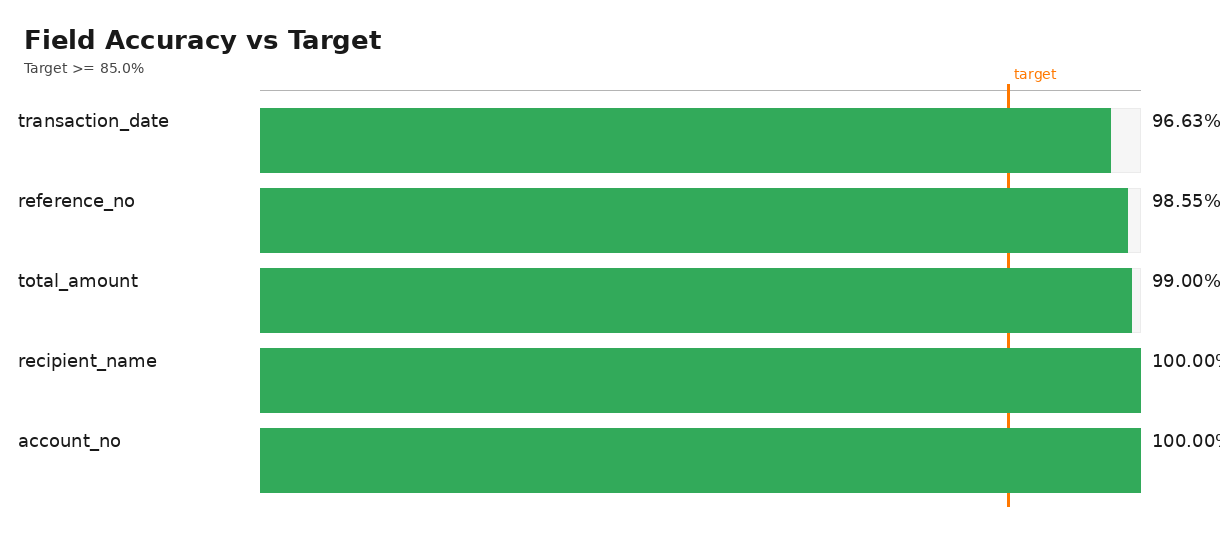

Saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/chart_field_accuracy_100.png


### Visual 2 - Latency Histogram + CDF

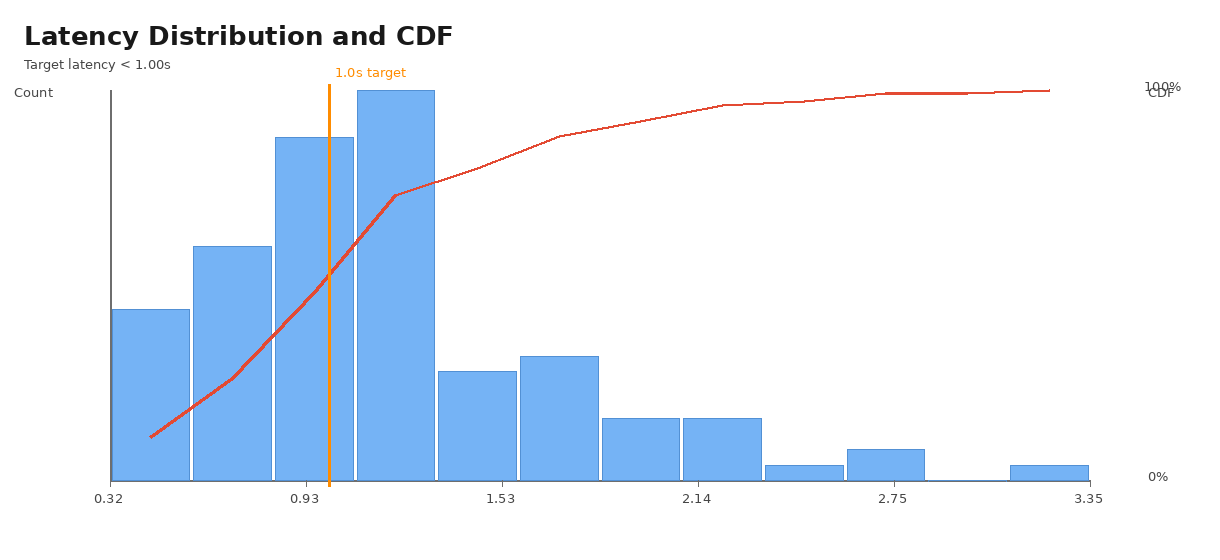

Saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/chart_latency_100.png


### Visual 3 - Template x Field Failure Heatmap

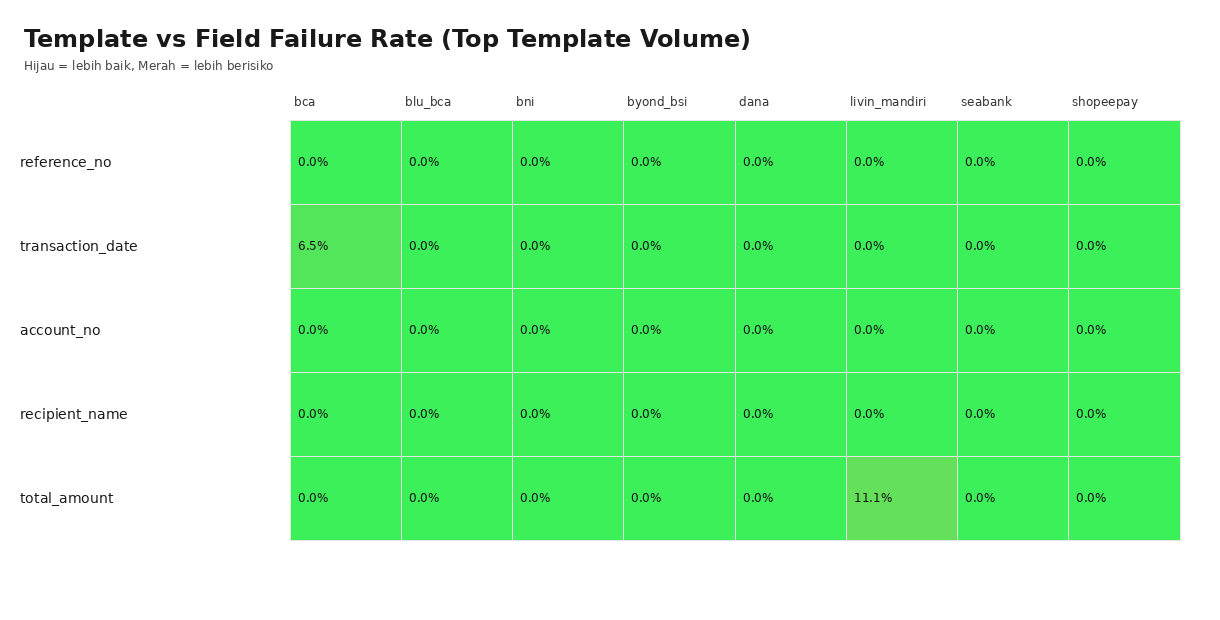

Saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/chart_template_field_heatmap_100.png


In [7]:
display(Markdown('### Visual 1 - Field Accuracy'))
img_acc = draw_accuracy_bar(per_field, target=ACCURACY_TARGET)
save_and_show(img_acc, f'chart_field_accuracy_{suffix}.png')


display(Markdown('### Visual 2 - Latency Histogram + CDF'))
img_lat = draw_latency_hist_cdf(df_row['latency_seconds'].values, target=LATENCY_TARGET, bins=12)
save_and_show(img_lat, f'chart_latency_{suffix}.png')


display(Markdown('### Visual 3 - Template x Field Failure Heatmap'))
img_heat = draw_template_field_heatmap(df_field, top_k_templates=8)
save_and_show(img_heat, f'chart_template_field_heatmap_{suffix}.png')


In [8]:
display(Markdown('### Breakdown Error per Field'))
status_breakdown = (
    df_field[df_field['has_gt'] == True]
    .groupby(['field', 'status'])
    .size()
    .unstack(fill_value=0)
)
status_ratio = status_breakdown.div(status_breakdown.sum(axis=1), axis=0).round(4)

display(status_breakdown)
display((status_ratio * 100).round(2).add_suffix('_pct'))


display(Markdown('### Confidence Bucket vs Match Rate'))
conf_df = eval_df.copy()
conf_df['confidence_bucket'] = pd.cut(
    conf_df['confidence'].astype(float),
    bins=[-0.001, 0.4, 0.6, 0.75, 0.9, 1.0],
    labels=['0.00-0.40', '0.40-0.60', '0.60-0.75', '0.75-0.90', '0.90-1.00']
)

conf_table = (
    conf_df.groupby(['field', 'confidence_bucket'])['match']
    .agg(samples='size', match_rate='mean')
    .reset_index()
)
conf_table['match_rate_pct'] = (conf_table['match_rate'] * 100).round(2)
display(conf_table.sort_values(['field', 'confidence_bucket']))


display(Markdown('### Source Contribution (Rule vs Model Fallback)'))
source_mix = (
    eval_df.groupby(['field', 'source'])
    .size()
    .unstack(fill_value=0)
)
source_mix_ratio = source_mix.div(source_mix.sum(axis=1), axis=0).round(4)

display(source_mix)
display((source_mix_ratio * 100).round(2).add_suffix('_pct'))


### Breakdown Error per Field

status,correct,miss_empty,wrong_value
field,,,
account_no,96,0,0
recipient_name,99,0,0
reference_no,68,1,0
total_amount,99,0,1
transaction_date,86,0,3


status,correct_pct,miss_empty_pct,wrong_value_pct
field,,,
account_no,100.00,0.00,0.00
recipient_name,100.00,0.00,0.00
reference_no,98.55,1.45,0.00
total_amount,99.00,0.00,1.00
transaction_date,96.63,0.00,3.37


### Confidence Bucket vs Match Rate

,field,confidence_bucket,samples,match_rate,match_rate_pct
0,account_no,0.75-0.90,40,1.000000,100.00
1,account_no,0.90-1.00,56,1.000000,100.00
2,recipient_name,0.75-0.90,7,1.000000,100.00
3,recipient_name,0.90-1.00,92,1.000000,100.00
4,reference_no,0.00-0.40,1,0.000000,0.00
5,reference_no,0.60-0.75,4,1.000000,100.00
6,reference_no,0.90-1.00,64,1.000000,100.00
7,total_amount,0.75-0.90,42,1.000000,100.00
8,total_amount,0.90-1.00,58,0.982759,98.28
9,transaction_date,0.75-0.90,2,1.000000,100.00


### Source Contribution (Rule vs Model Fallback)

source,none,rules_v1
field,,
account_no,0,96
recipient_name,0,99
reference_no,1,68
total_amount,0,100
transaction_date,0,89


source,none_pct,rules_v1_pct
field,,
account_no,0.00,100.00
recipient_name,0.00,100.00
reference_no,1.45,98.55
total_amount,0.00,100.00
transaction_date,0.00,100.00


In [9]:
display(Markdown('### Hard Cases - Monitoring Wajib (5 Kasus Prioritas)'))

def evaluate_hard_cases_live(images):
    rows = load_rows(Path(GROUND_TRUTH_PATH))
    gt_by_image = {row.get('image'): row.get('ground_truth', {}) for row in rows}

    extractor = ReceiptFieldExtractorV2()

    field_rows = []
    row_rows = []

    for image_name in images:
        gt = HARD_CASE_EXPECTED.get(image_name) or gt_by_image.get(image_name, {})
        image_path = Path(IMAGE_DIR) / image_name

        pred = {}
        confidence_map = {}
        source_map = {}
        template = 'unknown'
        latency = float('nan')
        error_text = None

        t0 = time.perf_counter()
        try:
            output = extractor.predict(str(image_path), return_meta=True)
            pred = output.get('data', {}) or {}
            confidence_map = output.get('confidence', {}) or {}
            source_map = output.get('source', {}) or {}
            template = output.get('template', 'unknown')
            latency = float(output.get('latency_seconds', time.perf_counter() - t0) or 0.0)
        except Exception as exc:
            error_text = str(exc)
            latency = float(time.perf_counter() - t0)

        row_total = 0
        row_correct = 0

        for field in FIELDS:
            gt_raw = gt.get(field)
            pred_raw = pred.get(field)
            has_gt = gt_raw is not None

            gt_norm = normalize_field_value(field, gt_raw) if has_gt else None
            pred_norm = normalize_field_value(field, pred_raw)

            if has_gt:
                matched = bool(is_match(field, pred_raw, gt_raw))
                row_total += 1
                row_correct += int(matched)
            else:
                matched = np.nan

            status = classify_status(gt_raw, pred_raw, bool(matched) if pd.notna(matched) else (pred_raw is None))

            field_rows.append({
                'image': image_name,
                'field': field,
                'gt_raw': gt_raw,
                'pred_raw': pred_raw,
                'gt_norm': gt_norm,
                'pred_norm': pred_norm,
                'has_gt': has_gt,
                'match': matched,
                'status': status,
                'confidence': float(confidence_map.get(field, np.nan)),
                'source': source_map.get(field),
                'template': template,
                'latency_seconds': latency,
                'error': error_text,
            })

        row_rows.append({
            'image': image_name,
            'template': template,
            'latency_seconds': latency,
            'field_total': row_total,
            'field_correct': row_correct,
            'row_accuracy': (row_correct / row_total) if row_total else np.nan,
            'error': error_text,
        })

    return pd.DataFrame(field_rows), pd.DataFrame(row_rows)

hard_case_live_fields, hard_case_live_rows = evaluate_hard_cases_live(HARD_CASE_IMAGES)

hard_case_live_rows = hard_case_live_rows.set_index('image').reindex(HARD_CASE_IMAGES).reset_index()
display(hard_case_live_rows[['image', 'template', 'row_accuracy', 'latency_seconds', 'field_correct', 'field_total', 'error']])

hard_case_eval = hard_case_live_fields[hard_case_live_fields['has_gt'] == True].copy()
hard_match_matrix = hard_case_eval.pivot_table(
    index='image',
    columns='field',
    values='match',
    aggfunc='mean'
).reindex(HARD_CASE_IMAGES)

display(Markdown('#### Match Rate per Field (Hard Cases - Live Extractor)'))
display((hard_match_matrix * 100).round(2).add_suffix('_pct'))

unresolved = hard_case_eval[hard_case_eval['match'] != 1]
if unresolved.empty:
    display(Markdown('✅ Semua field ber-ground-truth pada 5 hard cases sudah match dengan expected/ground truth.'))
else:
    display(Markdown('⚠️ Masih ada field hard case yang belum match:'))
    display(unresolved[['image', 'field', 'status', 'gt_raw', 'pred_raw', 'confidence', 'source']].sort_values(['image', 'field']))

for img in HARD_CASE_IMAGES:
    display(Markdown(f'#### Detail Hard Case (Live): `{img}`'))
    detail = hard_case_eval[hard_case_eval['image'] == img][[
        'field', 'status', 'gt_raw', 'pred_raw', 'confidence', 'source', 'match', 'latency_seconds'
    ]].sort_values('field')
    display(detail)

# Tetap tampilkan backlog global terburuk dari evaluasi batch
# (berguna untuk prioritas selain 5 hard case)
display(Markdown('### Backlog Global - Row dengan Akurasi Terendah (Batch Eval)'))
hard_rows = df_row.sort_values(['row_accuracy', 'latency_seconds'], ascending=[True, False]).head(15)
display(hard_rows[['image', 'template', 'row_accuracy', 'latency_seconds', 'field_correct', 'field_total', 'error']])



### Hard Cases - Monitoring Wajib (5 Kasus Prioritas)

,image,template,row_accuracy,latency_seconds,field_correct,field_total,error
0,33.jpg,seabank,1.0,2.4214,4,4,None
1,311.jpeg,dana,1.0,1.3262,5,5,None
2,61.jpg,bca,1.0,0.9755,3,3,None
3,39.jpg,livin_mandiri,1.0,0.8311,4,4,None
4,5.jpg,NaN,1.0,1.7312,4,4,None


#### Match Rate per Field (Hard Cases - Live Extractor)

field,account_no_pct,recipient_name_pct,reference_no_pct,total_amount_pct,transaction_date_pct
image,,,,,
33.jpg,100.0,100.0,100.0,100.0,NaN
311.jpeg,100.0,100.0,100.0,100.0,100.0
61.jpg,100.0,100.0,NaN,100.0,NaN
39.jpg,100.0,100.0,NaN,100.0,100.0
5.jpg,100.0,100.0,NaN,100.0,100.0


✅ Semua field ber-ground-truth pada 5 hard cases sudah match dengan expected/ground truth.

...

,field,status,gt_raw,pred_raw,confidence,source,match,latency_seconds
17,account_no,correct,7425252836,7425252836,0.98,rules_v1,True,0.8311
18,recipient_name,correct,Fadhil Bawazier,Fadhil Bawazier,0.92,rules_v1,True,0.8311
19,total_amount,correct,108000,108000,0.84,rules_v1,True,0.8311
16,transaction_date,correct,2026-04-03 15:03,2026-04-03 15:03,0.91,rules_v1,True,0.8311


#### Detail Hard Case (Live): `5.jpg`

,field,status,gt_raw,pred_raw,confidence,source,match,latency_seconds
22,account_no,correct,7425252836,7425252836,0.98,rules_v1,True,1.7312
23,recipient_name,correct,Fadhil Bawazier,Fadhil Bawazier,0.96,rules_v1,True,1.7312
24,total_amount,correct,300000,300000,0.84,rules_v1,True,1.7312
21,transaction_date,correct,2026-04-01 14:45,2026-04-01 14:45,0.91,rules_v1,True,1.7312


### Backlog Global - Row dengan Akurasi Terendah (Batch Eval)

,image,template,row_accuracy,latency_seconds,field_correct,field_total,error
32,35.jpg,bca,0.75,0.4065,3,4,None
84,121.jpg,NaN,0.80,1.7103,4,5,None
71,77.jpg,bca,0.80,1.0346,4,5,None
97,346.jpg,livin_mandiri,0.80,1.0189,4,5,None
54,57.jpg,bca,0.80,0.8611,4,5,None
31,34.jpg,bca,1.00,3.3547,5,5,None
30,33.jpg,seabank,1.00,2.8139,4,4,None
26,28.jpg,bni,1.00,2.7277,5,5,None
11,13.jpg,bca,1.00,2.3496,3,3,None
88,152.jpg,NaN,1.00,2.3133,3,3,None


In [10]:
# Auto-conclusion: evaluasi target readiness
under_target_fields = per_field[per_field['accuracy'] < ACCURACY_TARGET][['field', 'accuracy']]
lat_mean_ok = summary['latency']['mean'] is not None and summary['latency']['mean'] < LATENCY_TARGET
lat_p95_ok = summary['latency']['p95'] is not None and summary['latency']['p95'] < LATENCY_TARGET

if 'hard_case_live_fields' in globals():
    hard_case_eval = hard_case_live_fields[hard_case_live_fields['has_gt'] == True].copy()
else:
    hard_case_eval = eval_df[eval_df['image'].isin(HARD_CASE_IMAGES)].copy()

hard_case_accuracy = float(np.nanmean(hard_case_eval['match'])) if len(hard_case_eval) else float('nan')
hard_case_unresolved = hard_case_eval[hard_case_eval['match'] != 1] if len(hard_case_eval) else pd.DataFrame()

conclusion_lines = []
conclusion_lines.append(f"Samples dievaluasi: {summary['samples']}")
conclusion_lines.append(f"Summary source: {summary.get('summary_source', 'notebook_detailed')}")
conclusion_lines.append(f"Overall accuracy: {summary['overall_accuracy']*100:.2f}%")
conclusion_lines.append(
    f"Latency mean/p95/max: {summary['latency']['mean']:.4f}s / {summary['latency']['p95']:.4f}s / {summary['latency']['max']:.4f}s"
)

if len(under_target_fields) == 0:
    conclusion_lines.append(f"Semua field memenuhi target akurasi >= {ACCURACY_TARGET*100:.1f}%")
else:
    bad = ', '.join([f"{r.field} ({r.accuracy*100:.2f}%)" for r in under_target_fields.itertuples()])
    conclusion_lines.append(f"Field di bawah target akurasi >= {ACCURACY_TARGET*100:.1f}%: {bad}")

if lat_mean_ok and lat_p95_ok:
    conclusion_lines.append(f"Latency mean dan p95 sudah memenuhi target < {LATENCY_TARGET:.2f}s")
else:
    conclusion_lines.append(f"Latency belum memenuhi target < {LATENCY_TARGET:.2f}s secara konsisten (cek mean/p95)")

if len(hard_case_eval):
    conclusion_lines.append(f"Hard case accuracy (5 kasus terpantau): {hard_case_accuracy*100:.2f}%")
    if len(hard_case_unresolved) == 0:
        conclusion_lines.append('Semua hard case sudah match di seluruh field yang memiliki ground truth.')
    else:
        unresolved_pairs = hard_case_unresolved[['image', 'field']].drop_duplicates()
        unresolved_text = ', '.join([f"{r.image}:{r.field}" for r in unresolved_pairs.itertuples(index=False)])
        conclusion_lines.append(f"Masih ada hard case yang belum match: {unresolved_text}")

conclusion_md = "### Kesimpulan Otomatis\n" + "\n".join([f'- {line}' for line in conclusion_lines])
display(Markdown(conclusion_md))



### Kesimpulan Otomatis
- Samples dievaluasi: 100
- Summary source: evaluate_v2.py
- Overall accuracy: 98.90%
- Latency mean/p95/max: 1.0987s / 2.2983s / 2.8633s
- Semua field memenuhi target akurasi >= 85.0%
- Latency belum memenuhi target < 1.00s secara konsisten (cek mean/p95)
- Hard case accuracy (5 kasus terpantau): 100.00%
- Semua hard case sudah match di seluruh field yang memiliki ground truth.